# Temperature as a glowing flame / plume (the CAMS aerosol technique, recoloured for heat)

This reproduces the look of ECMWF's CAMS **Aerosol Optical Depth** animation — a dark, hillshaded Earth with
glowing, wispy plumes — but the field is **2 m temperature**, not organic matter / dust, and the colours are
a flame ramp instead of the aerosol pink / brown.

The glow is cleopatra's `alpha_scaled_image`: each pixel's **opacity is tied to its value** (cool → transparent,
so the dark terrain shows through; hot → opaque, glowing), and the colour comes from a flame ramp.

Both flame flavours are now shipped in cleopatra, so you always have both:
- **`FLAME_COLORMAPS["white_hot"]`** — black → red → yellow → white; the hottest areas blow out to yellow-white (most fire-like).
- **`FLAME_COLORMAPS["amber"]`** — a warmer gold/orange ramp, less blown-out.

and packaged as one-call data-style presets **`temperature_flame`** (white-hot) and **`temperature_flame_amber`**,
which carry the flame colour ramp *and* the value-linked opacity (compose them over a dark basemap, exactly
like the `haze` style).

In [1]:
import matplotlib

matplotlib.use("Agg")

import io
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image as IPyImage
from matplotlib.animation import FuncAnimation
from matplotlib.colors import Normalize

import cleopatra.reference as ref
from cleopatra.animation import embed_gif
from cleopatra.colors import FLAME_COLORMAPS, alpha_scaled_image, apply_data_style
from cleopatra.styles import apply_blank_canvas

# --- data ---
npz = np.load(Path("../../../examples/data/europe_t2m.npz"), allow_pickle=True)
celsius = npz["celsius"][::2]  # every other day, 23 frames, to keep the GIFs light
labels = list(npz["labels"])[::2]
west, south, east, north = (float(v) for v in npz["extent"])
ext = [west, east, south, north]

# --- both flame ramps, straight from the library ---
FLAMES = {
    "A — white-hot": FLAME_COLORMAPS["white_hot"],
    "B — amber": FLAME_COLORMAPS["amber"],
}

# colour spans 0..40 C; opacity ramps in over 6..32 C (cool fades into terrain, hot glows).
# These are the same defaults baked into the `temperature_flame` presets.
COLOR_NORM = Normalize(0, 40)
ALPHA_NORM = Normalize(6, 32)


def draw_backdrop(ax):
    """Dark hillshaded Earth: darkened relief + faint coastlines/borders.

    The axes are EPSG:4326 lon/lat, so `add_relief` is called WITHOUT `extent`:
    it draws the global relief at true coordinates and the axis limits (set to
    the European view below) crop it. Passing `extent=` here is for non-4326
    axes and would squash the whole world into the European box.
    """
    apply_blank_canvas(ax)
    ax.set_xlim(ext[0], ext[1])
    ax.set_ylim(ext[2], ext[3])
    ref.add_relief(ax, "medium", alpha=0.45, zorder=-2)
    ref.add_features(ax, "coastline", "50m", color="0.5", linewidth=0.5, zorder=2)
    ref.add_features(ax, "borders", "50m", color="0.35", linewidth=0.4, zorder=2)


def draw_glow(ax, field, cmap):
    return alpha_scaled_image(
        ax,
        field,
        cmap,
        norm=COLOR_NORM,
        alpha_norm=ALPHA_NORM,
        extent=ext,
        origin="upper",
        zorder=3,
    )


def show(fig):
    """Render a figure to an inline PNG (deterministic under the Agg backend)."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, facecolor="black", bbox_inches="tight")
    plt.close(fig)
    return IPyImage(data=buf.getvalue())


print("flame colormaps:", list(FLAME_COLORMAPS))
print("stack:", celsius.shape, "| frames:", labels[0], "->", labels[-1])

flame colormaps: ['white_hot', 'amber']
stack: (23, 111, 164) | frames: Jun 01 -> Jul 15


## Still comparison — the hottest day (15 Jul) in both flame flavours

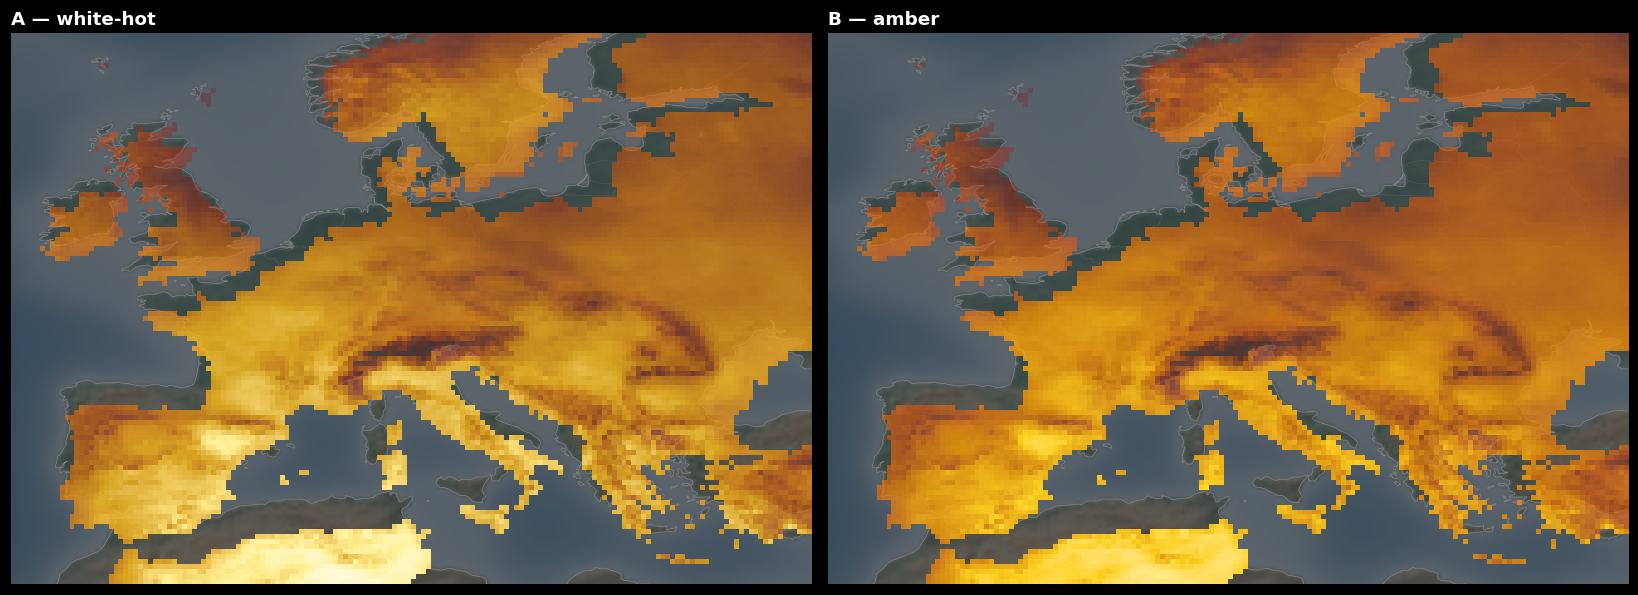

In [2]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor("black")
for ax, (name, cmap) in zip(axs, FLAMES.items()):
    draw_backdrop(ax)
    draw_glow(ax, celsius[-1], cmap)
    ax.set_title(name, color="white", loc="left", fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
show(fig)

## Animation A — white-hot

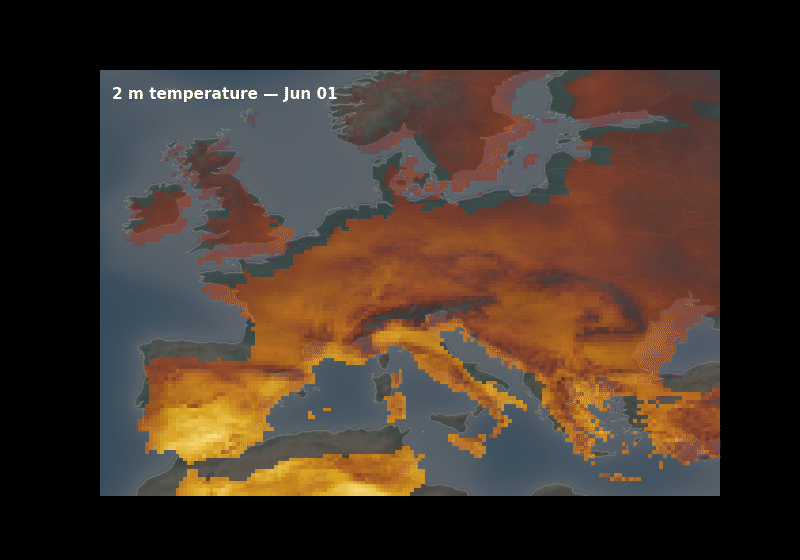

In [3]:
def flame_animation(cmap):
    """Static dark backdrop drawn once; only the glowing overlay updates per frame."""
    fig, ax = plt.subplots(figsize=(8, 5.6))
    fig.patch.set_facecolor("black")
    draw_backdrop(ax)
    ax.set_xticks([])
    ax.set_yticks([])
    state = {"im": None, "txt": None}

    def update(i):
        if state["im"] is not None:
            state["im"].remove()
        state["im"] = draw_glow(ax, celsius[i], cmap)
        if state["txt"] is not None:
            state["txt"].remove()
        state["txt"] = ax.text(
            0.02,
            0.96,
            f"2 m temperature — {labels[i]}",
            transform=ax.transAxes,
            color="white",
            fontsize=11,
            fontweight="bold",
            va="top",
        )
        return [state["im"], state["txt"]]

    return FuncAnimation(fig, update, frames=len(celsius), interval=140)


anim_a = flame_animation(FLAMES["A — white-hot"])
gif_a = embed_gif(anim_a, fps=8)
plt.close("all")
gif_a

## Animation B — amber

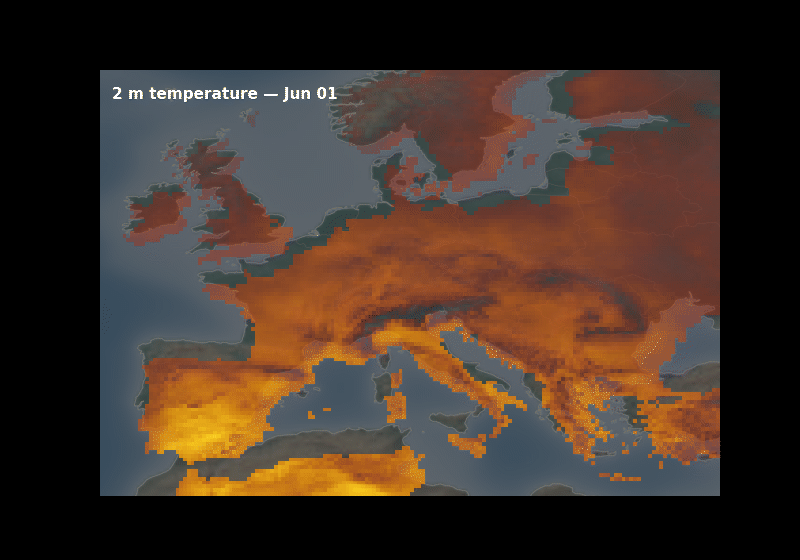

In [4]:
anim_b = flame_animation(FLAMES["B — amber"])
gif_b = embed_gif(anim_b, fps=8)
plt.close("all")
gif_b

## The packaged presets (one call)

The same look via the shipped data-style presets — the flame ramp **and** the value-linked opacity in one
call. Compose over the dark backdrop just like above; here is a still of each on the hottest day.

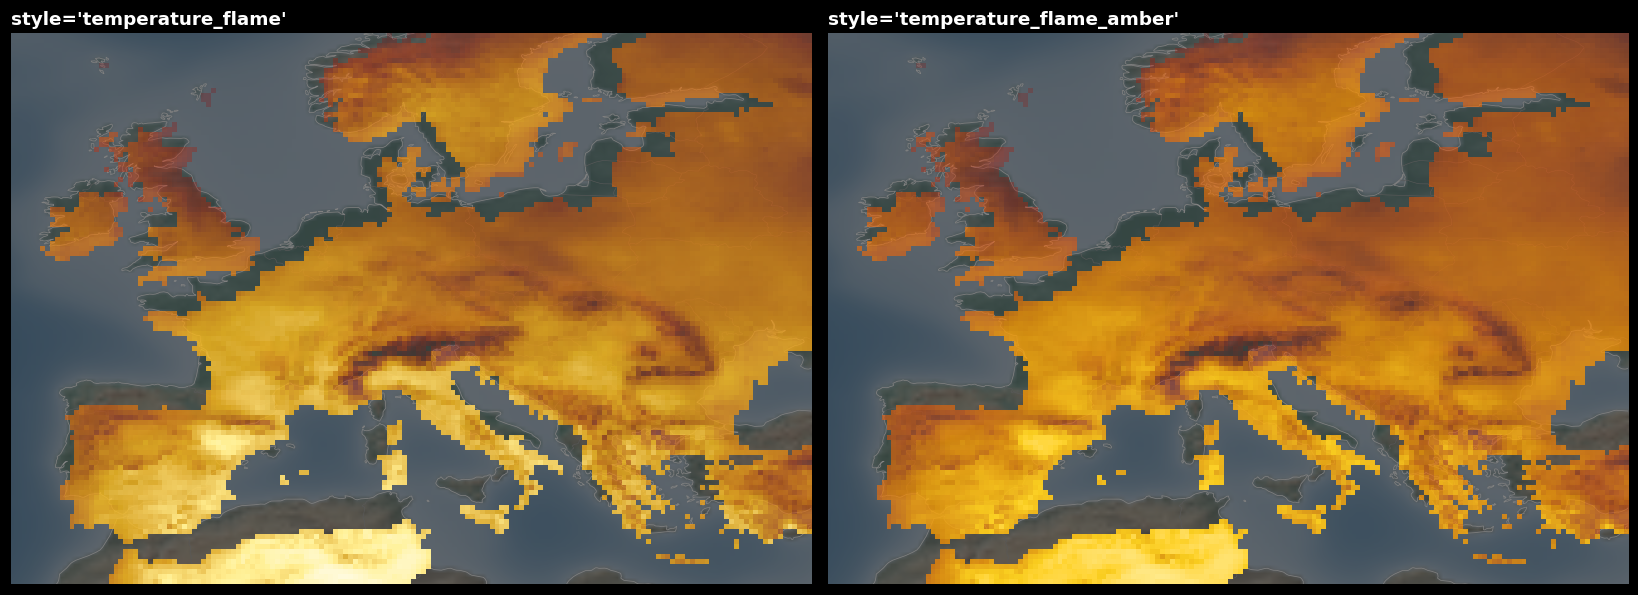

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor("black")
for ax, style in zip(axs, ["temperature_flame", "temperature_flame_amber"]):
    draw_backdrop(ax)
    apply_data_style(
        ax,
        {style: celsius[-1]},
        style=style,
        legend=False,
        extent=ext,
        origin="upper",
        zorder=3,
    )
    ax.set_title(f"style='{style}'", color="white", loc="left", fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
show(fig)